In [ ]:
# MNIST Image Denoising using Autoencoder

## Objective

This notebook demonstrates an Autoencoder model that removes random noise from handwritten MNIST digit images using PyTorch.

In [1]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from model import Autoencoder

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Autoencoder().to(device)
model.load_state_dict(torch.load("autoencoder.pth", map_location=device))
model.eval()

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [3]:
transform = transforms.ToTensor()

test_dataset = datasets.MNIST(
    root="./dataset",
    train=False,
    download=True,
    transform=transform
)

image, _ = test_dataset[0]
image = image.unsqueeze(0).to(device)

noise = torch.randn_like(image) * 0.5
noisy = torch.clamp(image + noise, 0, 1)

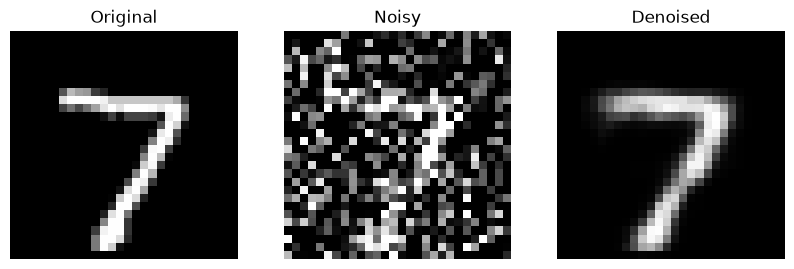

In [4]:
with torch.no_grad():
    output = model(noisy)

plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(image.squeeze().cpu(), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy.squeeze().cpu(), cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(output.squeeze().cpu(), cmap="gray")
plt.title("Denoised")
plt.axis("off")

plt.show()